In [1]:
# uv add python-dotenv langchain langchain_google_genai
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    temperature = 0
)

In [2]:
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage
import operator

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [3]:
def llm_node(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [10]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

graph_builder = StateGraph(MessagesState)

graph_builder.add_node("llm", llm_node)

graph_builder.add_edge(START, "llm")
graph_builder.add_edge("llm", END)

checkpointer = InMemorySaver()
graph = graph_builder.compile(checkpointer=checkpointer)

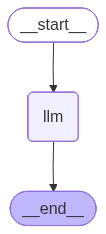

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
config = {"configurable": {"thread_id": "conversation_1"}}

In [14]:
from langchain_core.messages import HumanMessage

result = graph.invoke({"messages": [HumanMessage(content="내 이름은 김일남이야.")]}, config=config)

In [15]:
result

{'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='네, 김일남 님이시군요. 반갑습니다!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8403-b078-7340-ac03-6567cc84efec-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 733, 'total_tokens': 742, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 721}})]}

In [16]:
result = graph.invoke({"messages": [HumanMessage(content="내 이름 뭐야?")]}, config=config)


In [17]:
result

{'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='네, 김일남 님이시군요. 반갑습니다!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8403-b078-7340-ac03-6567cc84efec-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 733, 'total_tokens': 742, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 721}}),
  HumanMessage(content='내 이름 뭐야?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='김일남 님이십니다.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8404-44a8-7f83-91c4-4321b76e8c6b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 27, 'output_tokens': 167, 'total_tokens': 194, 'inpu

In [18]:
config = {"configurable": {"thread_id": "conversation_2"}}

In [19]:
result = graph.invoke({"messages": [HumanMessage(content="내 이름 뭐야?")]}, config=config)

In [20]:
result

{'messages': [HumanMessage(content='내 이름 뭐야?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='저는 인공지능이기 때문에 당신의 이름을 알 수 없습니다. 당신이 직접 알려주지 않는 한, 저는 개인 정보를 가지고 있지 않아요.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8405-53f5-7ab1-8325-9d3a71a1c2fc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 108, 'total_tokens': 113, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 77}})]}